In [1]:
import sys
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

import threading
from concurrent.futures import ThreadPoolExecutor

import magcal
from thread_func import thread_func

### Differential inversion
L1-L2 penalty

$$
P(\boldsymbol{\delta \beta}) =  \lambda_1 \left\| \boldsymbol{\delta \beta} \right\|_1 + \frac{\lambda_2}{2} \| \boldsymbol{\delta \beta} \|_2^2
$$

In [2]:
# class for L1-L2 penalty inversion
from L1L2_penalty_inv import L1L2

In [3]:
# data misfit
def misfit(f, K, beta_star):
    return 0.5 * np.linalg.norm(f - K.dot(beta_star))**2

# penalty
def pen(beta, alpha):
    pen_1 = np.linalg.norm(beta, 1)
    pen_2 = 0.5 * np.linalg.norm(beta, 2)**2
    pen_all = alpha * pen_1 + (1. - alpha) * pen_2
    return pen_all

In [4]:
def calcCurvature2(x,y):
    
    dif_x = np.gradient(x)
    dif_y = np.gradient(y)
    dif2_x = np.gradient(dif_x)
    dif2_y = np.gradient(dif_y)
    
    curvature = np.abs(dif2_x * dif_y - dif_x * dif2_y) / (dif_x **2 + dif_y **2)**1.5
    return curvature

### 空間領域

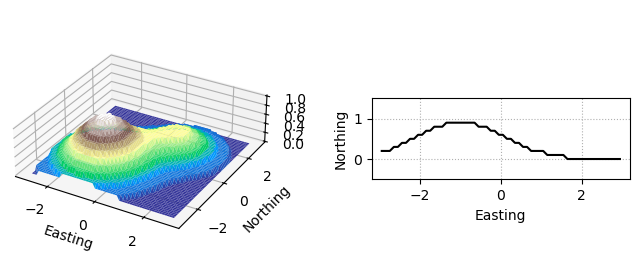

In [5]:
### 地下グリッドの作成: xgrd, ygrd, zgrd ###
# incx, incy, incz : x, y, z方向のグリッド間隔
incx = 0.1
incy = 0.1
incz = 0.1

x = np.arange(-3.0 + 0.5*incx, 3.0, incx)
y = np.arange(-3.0 + 0.5*incy, 3.0, incy)
nx = len(x)
ny = len(y)

# 山×2（北東・南西）
from scipy.ndimage import gaussian_filter

X, Y = np.meshgrid(x, y)

# 北東の山
A1 = 0.5
x1, y1 = 1.0, 1.0
sigma1 = 1.25
z1 = A1 * np.exp(-((X - x1)**2 + (Y - y1)**2) / sigma1**2)

# 南西の山
A2 = 1.0
x2, y2 = -1.0, -1.0
sigma2 = 1.5
z2 = A2 * np.exp(-((X - x2)**2 + (Y - y2)**2) / sigma2**2)

# 合成地形
T = z1 + z2

# --- DEM風ノイズの追加 ---
np.random.seed(42)

# 白色ノイズ
noise = np.random.normal(0, 0.15, size=T.shape)

# 空間相関を持たせる（ガウシアンフィルタ）
noise_smooth = gaussian_filter(noise, sigma=1.0)

# ノイズを加える
#T += noise_smooth

# 0.1 刻みに丸める
T = np.round(T / 0.1) * 0.1

### 地下グリッドの作成: xgrd, ygrd, zgrd ###
# 地下の層数 = 30  # 60×60×30
nz = 30
[yy2, zz2, xx2] = np.meshgrid(y, np.zeros(nz), x)

for k in range(nz):
    for i in range(nx):
        for j in range(ny):
            zz2[k, j, i] = T.reshape(-1)[i + nx*j] - incz / 2. - incz*k
            
xgrd = xx2.reshape(-1)
ygrd = yy2.reshape(-1)
zgrd = zz2.reshape(-1)

# 図示用
xfig, yfig, zfig = [], [], []

for i in range(len(xgrd)):
    j = i // (nx*ny)
    
    # 各グリッドの8頂点の座標を格納
    xfig.append([xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, 
                 xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx])
    yfig.append([ygrd[i] - 0.5*incy, ygrd[i] - 0.5*incy, ygrd[i] + 0.5*incy, ygrd[i] + 0.5*incy, 
                 ygrd[i] - 0.5*incy, ygrd[i] - 0.5*incy, ygrd[i] + 0.5*incy, ygrd[i] + 0.5*incy])
    zfig.append([zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, 
                 zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz])

# array化
xfig = np.array(xfig)
yfig = np.array(yfig)
zfig = np.array(zfig)

#dim: ブロックのサイズ
dim = [[incx / 2., incx / 2.], [incy / 2., incy / 2.], [incz / 2., incz / 2.]]

# 東京付近
# 偏角(度)
dec = -7.
# 伏角(度)
inc = 50.

# 図示
fig = plt.figure(figsize = (8, 4))
plt.subplots_adjust(wspace=0.4, hspace=0.)

ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(X, Y, T, rstride=1, cstride=1, cmap = plt.cm.terrain)
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
ax.set_box_aspect((1,1,0.3))

ax = fig.add_subplot(122)
ys = 15
ax.plot(X[ys, :], T[ys,:], color = "black")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
ax.set_aspect("equal")
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(-0.5, 1.5)
ax.grid(linestyle = "dotted")

Text(0.5, 1.0, 'NE–SW Cross-section (No Interpolation)')

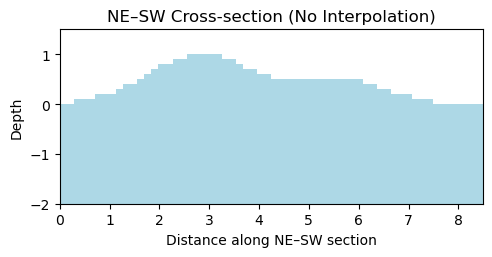

In [6]:
from matplotlib.patches import Rectangle

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(122)

tol = 0.05   # 断面幅（必要に応じて調整）

# 断面（NE-SW）
for i in range(len(xgrd)):

    # ボクセルの8頂点
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW 断面条件： y ≈ x ---
    # ボクセルの中心
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # 断面方向の距離軸（南西→北東）
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # 矩形を描画（補間なし）
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor="lightblue", edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

# 軸設定
ax.set_xlim(0, np.sqrt( (3 - (-3))**2 * 2 ))  # 対角線距離
ax.set_ylim(-2.0, 1.5)
ax.set_aspect("equal")
ax.set_xlabel("Distance along NE–SW section")
ax.set_ylabel("Depth")
ax.set_title("NE–SW Cross-section (No Interpolation)")


### 空中磁気探査（正規グリッド）

CPU times: total: 12.5 s
Wall time: 12.8 s


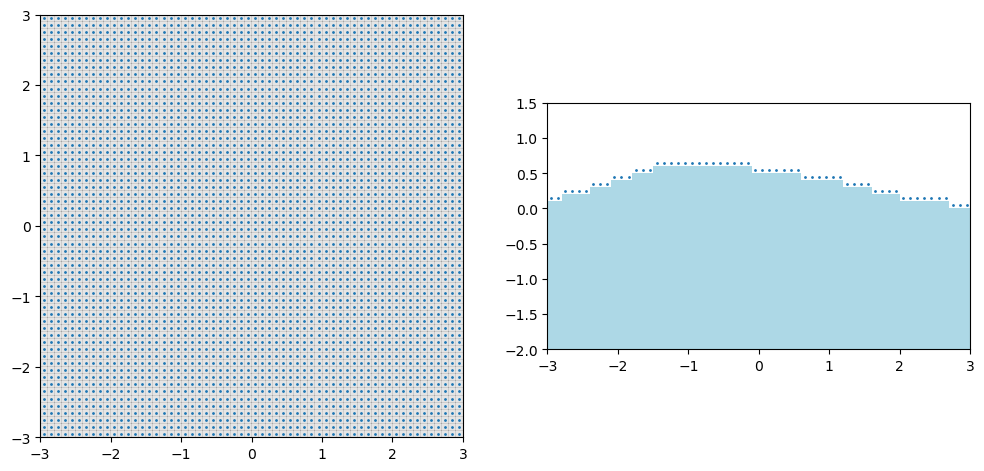

In [7]:
%%time
### 合成データの作成 ###
# 座標： x:東向きを正, y:北向きを正, z:鉛直上向きを正

### 観測点の作成: yobs, zobs ###
[xobs1, yobs1] = np.meshgrid(np.arange(-3.0 + 0.5*incx, 3.0, incx), np.arange(-3.0 + 0.5*incy, 3.0, incy))
xobs1 = xobs1.reshape(-1)
yobs1 = yobs1.reshape(-1)
zobs1 = np.zeros(len(xobs1))

for i in range(len(xobs1)):
    for j in range(len(X.reshape(-1))):
        if (abs(xobs1[i] - X.reshape(-1)[j]) < 1e-3) & (abs(yobs1[i] - Y.reshape(-1)[j]) < 1e-3):
            zobs1[i] = T.reshape(-1)[j] + 0.05 # 地表から 50 m

# 図示
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.colorbar as clb
from matplotlib import gridspec
from matplotlib.patches import Rectangle

fig = plt.figure(figsize = (12, 6))

ax = fig.add_subplot(121)
ax.pcolor(xx2[0,:,:], yy2[0,:,:], np.zeros(xx2[0,:,:].shape), cmap = "gray", alpha = 0.1)
ax.scatter(xobs1, yobs1, s = 1)
ax.set_aspect("equal")

ax = fig.add_subplot(122)

ax.scatter(xobs1[(0<yobs1)&(yobs1<incy)], zobs1[(0<yobs1)&(yobs1<incy)], s = 1)

# 断面
for i in range(len(xgrd)):
    
    # 座標
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # 条件
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # 直方体の縦横
        width  = x_max - x_min
        height = z_max - z_min

        # 矩形を描画
        rect = Rectangle((x_min, z_min), width, height, facecolor="lightblue", edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-2.0, 1.5)
ax.set_aspect("equal")

### Kernel matrix

In [8]:
%%time
# threadingを用いた並列計算で核行列を求める
# 単位ベクトル作成
mgz = magcal.di2xyz(dec = dec, inc = inc)
exf = mgz.copy()

# スレッドの数（並列計算を動かす数）
n = 12

# 全グリッドに関する計算範囲 i = [0, nz] を n 個に分割
p = np.linspace(0, nz - 1, n).astype(int)
p[-1] += 1
print(p)

# ThreadPool に各threadの返り値を格納させる
results = []

pool = ThreadPoolExecutor(max_workers=n-1)
for i in range(n - 1):
    p0 = p[i]
    p1 = p[i + 1]
    res = pool.submit(thread_func, p0, p1, mgz, xobs1, yobs1, zobs1, xgrd, ygrd, zgrd, dim, 1000.)
    results.append(res)

pool.shutdown()

# 計算結果を取り出し、積み上げて最終的な核行列にする
K1 = []
for res in results:
    Ki = res.result()
    if len(K1) == 0:
        K1 = Ki.copy()
    else:
        K1 = np.hstack((K1, Ki))

[ 0  2  5  7 10 13 15 18 21 23 26 30]
Processed cell index: 0
Processed cell index: 18000
Processed cell index: 54000
Processed cell index: 36000
Processed cell index: 83000
Processed cell index: 47000
Processed cell index: 65000
Processed cell index: 94000
Processed cell index: 76000
Processed cell index: 8000
Processed cell index: 26000
Processed cell index: 1000
Processed cell index: 55000
Processed cell index: 37000
Processed cell index: 19000
Processed cell index: 84000
Processed cell index: 66000
Processed cell index: 48000
Processed cell index: 95000
Processed cell index: 77000
Processed cell index: 9000
Processed cell index: 27000
Processed cell index: 2000
Processed cell index: 56000
Processed cell index: 38000
Processed cell index: 20000
Processed cell index: 85000
Processed cell index: 67000
Processed cell index: 49000
Processed cell index: 96000
Processed cell index: 78000
Processed cell index: 10000
Processed cell index: 28000
Processed cell index: 3000
Processed cell inde

In [9]:
# Depth weighting
w1 = np.linalg.norm(K1, axis=0)
X1 = K1 / w1

### Input models

In [10]:
### 磁化構造  ###

# 球状消磁源  
zcenter = -0.5
a_rad = 0.5
b_rad = 0.5
c_rad = 0.5

# 側方にダイク貫入
# 方向ベクトル（NE + 30° up）
d = np.array([
    np.cos(np.deg2rad(10)) / np.sqrt(2),
    np.cos(np.deg2rad(10)) / np.sqrt(2),
    np.sin(np.deg2rad(10))
])  # 正規化済み

# 中心
center = np.array([-0.95, -0.95, -0.2])

# ダイク半径
dike_r = 0.1

# グリッド点 → ダイク基点へのベクトル
dx = xx2 - center[0]
dy = yy2 - center[1]
dz = zz2 - center[2]

# 軸方向の距離 t（射影）
t = dx * d[0] + dy * d[1] + dz * d[2]

# 軸からの距離
px = center[0] + t * d[0]
py = center[1] + t * d[1]
pz = center[2] + t * d[2]

dist_axis = np.sqrt((xx2 - px)**2 + (yy2 - py)**2 + (zz2 - pz)**2)

# ------------------------------------------------------------ #
### Time1 ###
beta1 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if (xgrd[k] - center[0])**2 / a_rad**2 + (ygrd[k] - center[1])**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta1[k] = -5

# ダイク1
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if ((xgrd[k] - center[0])**2 + (ygrd[k] - center[1])**2 <= 0.15**2) & (0.2 <= zgrd[k]) & (zgrd[k] <= 0.8):
                beta1[k] = -4

### Time2 ###
beta2 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if (xgrd[k] - center[0])**2 / a_rad**2 + (ygrd[k] - center[1])**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta2[k] = -5
                
# ダイク1
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if ((xgrd[k] - center[0])**2 + (ygrd[k] - center[1])**2 <= 0.15**2) & (0.2 <= zgrd[k]) & (zgrd[k] <= 0.8):
                beta2[k] = -2

### Time3 ###
beta3 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if (xgrd[k] - center[0])**2 / a_rad**2 + (ygrd[k] - center[1])**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta3[k] = -5

# ダイク1
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if ((xgrd[k] - center[0])**2 + (ygrd[k] - center[1])**2 <= 0.15**2) & (0.2 <= zgrd[k]) & (zgrd[k] <= 0.8):
                beta3[k] = 1

# ダイク2
L3 = 2.6 # ダイク長さ
inside_dike = (dist_axis <= dike_r) & (t >= 0) & (t <= L3)
beta3.reshape(xx2.shape)[inside_dike] = -5

### Time4 ###
beta4 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if (xgrd[k] - center[0])**2 / a_rad**2 + (ygrd[k] - center[1])**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta4[k] = -5

# ダイク1
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if ((xgrd[k] + - center[0])**2 + (ygrd[k] - center[1])**2 <= 0.15**2) & (0.2 <= zgrd[k]) & (zgrd[k] <= 0.8):
                beta4[k] = 5

# ダイク2
L4 = 2.6 # ダイク長さ
inside_dike = (dist_axis <= dike_r) & (t >= 0) & (t <= L4)
beta4.reshape(xx2.shape)[inside_dike] = -5

# ------------------------------------------------------------ #

# 磁気異常の計算
f1_row = K1.dot(beta1)
f2_row = K1.dot(beta2)
f3_row = K1.dot(beta3)
f4_row = K1.dot(beta4)

# ガウシアンノイズを加える 
np.random.seed(42)
noise1 = np.random.normal(loc=0, scale=5.0, size=len(f1_row)) # 5nT
noise2 = np.random.normal(loc=0, scale=5.0, size=len(f2_row)) # 5nT
noise3 = np.random.normal(loc=0, scale=5.0, size=len(f3_row)) # 5nT
noise4 = np.random.normal(loc=0, scale=5.0, size=len(f4_row)) # 5nT
fobs1 = f1_row + noise1
fobs2 = f2_row + noise2
fobs3 = f3_row + noise3
fobs4 = f4_row + noise4

bb1 = beta1.reshape(nz, ny, nx)
bb2 = beta2.reshape(nz, ny, nx)
bb3 = beta3.reshape(nz, ny, nx)
bb4 = beta4.reshape(nz, ny, nx)

<timed exec>:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
<timed exec>:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
<timed exec>:340: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
<timed exec>:371: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
<timed exec>:402: MatplotlibDeprecationWarn

CPU times: total: 13.8 s
Wall time: 15.2 s


Text(0.5, 1.0, 'Magnetic anomaly (nT)')

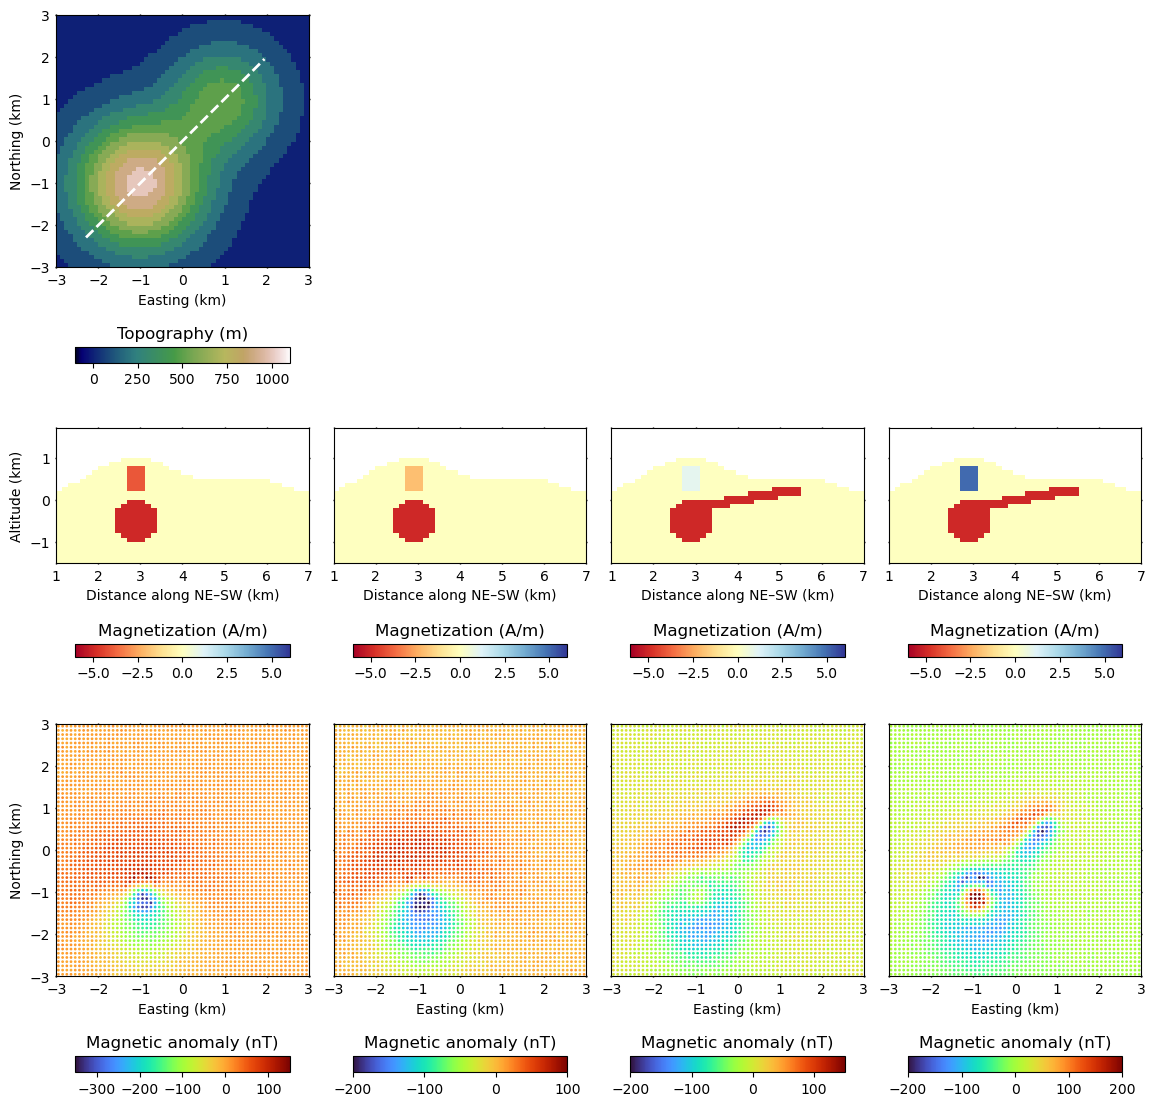

In [11]:
%%time
# カラーマップ
cmap = cm.get_cmap("gist_earth")
norm = Normalize(vmin = -100, vmax = 1100)

# 点線
# 視点と終点
P0 = np.array([-3, -3])
P1 = np.array([3, 3])

# 方向ベクトルと正規化
d = P1 - P0
d_norm = d / np.linalg.norm(d)

# 距離区間
t1, t2 = 1.0, 7.0

# 区間の点を生成
ts = np.linspace(t1, t2, 200)
points = P0 + np.outer(ts, d_norm)


# 図示
fig = plt.figure(figsize = (14, 12.5))
plt.subplots_adjust(wspace=0.1, hspace=-0.3)

#--- Topography ---#

ax = fig.add_subplot(541)
p = ax.pcolor(X, Y, T*1e3, cmap = cmap)
p.set_clim(-100, 1100)

ax.plot(points[:, 0], points[:, 1], linestyle='--', color='white', linewidth=2)

ax.set_aspect("equal")
ax.set_xlim(-3, )
ax.set_ylim(-3, )
ax.set_xlabel("Easting (km)")
ax.set_ylabel("Northing (km)")
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Topography (m)", fontsize = 12)


#--- Input model ---#

# カラーマップ
cmap = cm.get_cmap("RdYlBu")
norm = Normalize(vmin = -6, vmax = 6)

# T = T1
ax = fig.add_subplot(5,4,9)

# 断面（NE-SW）
for i in range(len(xgrd)):

    # ボクセルの8頂点
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW 断面条件： y ≈ x ---
    # ボクセルの中心
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # 断面方向の距離軸（南西→北東）
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # beta_forward の値に応じて色を取得
        beta_val = beta1[i]
        color = cmap(norm(beta_val))
        
        # 矩形を描画（補間なし）
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(0, np.sqrt( (3 - (-3))**2 * 2 ))  # 対角線距離
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
ax.set_xlabel("Distance along NE–SW (km)")
ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

# T = T2
ax = fig.add_subplot(5,4,10)

# 断面（NE-SW）
for i in range(len(xgrd)):

    # ボクセルの8頂点
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW 断面条件： y ≈ x ---
    # ボクセルの中心
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # 断面方向の距離軸（南西→北東）
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # beta_forward の値に応じて色を取得
        beta_val = beta2[i]
        color = cmap(norm(beta_val))
        
        # 矩形を描画（補間なし）
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(0, np.sqrt( (3 - (-3))**2 * 2 ))  # 対角線距離
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
ax.set_xlabel("Distance along NE–SW (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_2$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

# T = T_3
ax = fig.add_subplot(5,4,11)

# 断面（NE-SW）
for i in range(len(xgrd)):

    # ボクセルの8頂点
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW 断面条件： y ≈ x ---
    # ボクセルの中心
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # 断面方向の距離軸（南西→北東）
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # beta_forward の値に応じて色を取得
        beta_val = beta3[i]
        color = cmap(norm(beta_val))
        
        # 矩形を描画（補間なし）
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(0, np.sqrt( (3 - (-3))**2 * 2 ))  # 対角線距離
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
ax.set_xlabel("Distance along NE–SW (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_3$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

# T = T_4 
ax = fig.add_subplot(5,4,12)

# 断面（NE-SW）
for i in range(len(xgrd)):

    # ボクセルの8頂点
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)

    # --- NE-SW 断面条件： y ≈ x ---
    # ボクセルの中心
    xc = xgrd[i]
    yc = ygrd[i]

    if abs(yc - xc) < tol:

        # 断面方向の距離軸（南西→北東）
        dist_min = np.sqrt((x_min - (-3))**2 + (y_min - (-3))**2)
        dist_max = np.sqrt((x_max - (-3))**2 + (y_max - (-3))**2)

        width  = dist_max - dist_min
        height = z_max - z_min

        # beta_forward の値に応じて色を取得
        beta_val = beta4[i]
        color = cmap(norm(beta_val))
        
        # 矩形を描画（補間なし）
        rect = Rectangle((dist_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(0, np.sqrt( (3 - (-3))**2 * 2 ))  # 対角線距離
ax.set_xlim(1.0, 7.0)
ax.set_ylim(-1.5, 1.7)
ax.set_xlabel("Distance along NE–SW (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_4$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

### data ###

# T = T_1
ax = fig.add_subplot(5,4,17)
p = ax.scatter(xobs1, yobs1, c = fobs1, cmap = "turbo", s = 1)
#plt.colorbar(p)
p.set_clim(-350, 150)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_ylabel("Northing (km)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(width = 1, length = 1)

#--- colorbar ---# # その都度造り直す
cmap = cm.get_cmap("turbo")
norm = Normalize(vmin = -350, vmax = 150)
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Magnetic anomaly (nT)", fontsize = 12)

# T = T_2
ax = fig.add_subplot(5,4,18)
p = ax.scatter(xobs1, yobs1, c = fobs2, cmap = "turbo", s = 1)
#plt.colorbar(p)
p.set_clim(-200, 100)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---# # その都度造り直す
cmap = cm.get_cmap("turbo")
norm = Normalize(vmin = -200, vmax = 100)
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Magnetic anomaly (nT)", fontsize = 12)

# T = T_3
ax = fig.add_subplot(5,4,19)
p = ax.scatter(xobs1, yobs1, c = fobs3, cmap = "turbo", s = 1)
#plt.colorbar(p)
p.set_clim(-200, 150)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---# # その都度造り直す
cmap = cm.get_cmap("turbo")
norm = Normalize(vmin = -200, vmax = 150)
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Magnetic anomaly (nT)", fontsize = 12)

# T = T_4
ax = fig.add_subplot(5,4,20)
p = ax.scatter(xobs1, yobs1, c = fobs4, cmap = "turbo", s = 1)
#plt.colorbar(p)
p.set_clim(-200, 200)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, )
ax.tick_params(width = 1, length = 1)

#--- colorbar ---# # その都度造り直す
cmap = cm.get_cmap("turbo")
norm = Normalize(vmin = -200, vmax = 200)
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])  # 必須（中身は空でOK）
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.38, 1, 0.65), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
cbar.ax.set_title("Magnetic anomaly (nT)", fontsize = 12)

### Differential Inversion

In [12]:
# hyper-parameters
lams = np.power(10., np.arange(0.0, 2.6, 0.25))
print("lams = {}".format(lams))

# ratio of L1 norm and L2 norm
alpha_ = 0.9

lams = [  1.           1.77827941   3.16227766   5.62341325  10.
  17.7827941   31.6227766   56.23413252 100.         177.827941
 316.22776602]


In [13]:
%%time
params_all = []
betas_del12_all = []
betas_del23_all = []
betas_del34_all = []

for li in range(len(lams)):

    params_all.append(lams[li])
    
    l_1 = lams[li] * alpha_
    l_2 = lams[li] * (1. - alpha_)
    print("λ1 = {}, λ2 = {}".format(l_1, l_2))
    
    # インバージョン解析を実行
    model1 = L1L2(l_1, l_2, rho_=1.0, eta_=0., fit_intercept = False, eps_ADMM = 1.e-3)
    model1.algorithm(X1, fobs2 - fobs1, w1)
    beta_sim_del12 = model1.beta_ / w1
    
    model2 = L1L2(l_1, l_2, rho_=1.0, eta_=0., fit_intercept = False, eps_ADMM = 1.e-3)
    model2.algorithm(X1, fobs3 - fobs2, w1)
    beta_sim_del23 = model2.beta_ / w1
    
    model3 = L1L2(l_1, l_2, rho_=1.0, eta_=0., fit_intercept = False, eps_ADMM = 1.e-3)
    model3.algorithm(X1, fobs4 - fobs3, w1)
    beta_sim_del34 = model3.beta_ / w1

    betas_del12_all.append(beta_sim_del12)
    betas_del23_all.append(beta_sim_del23)
    betas_del34_all.append(beta_sim_del34)

# ndarry
params_all = np.array(params_all)
betas_del12_all = np.array(betas_del12_all)
betas_del23_all = np.array(betas_del23_all)
betas_del34_all = np.array(betas_del34_all)

λ1 = 0.9, λ2 = 0.09999999999999998
intercept = False
no-constrained
iter = 0, delta = 0.38560464529024985
Converged at iteration 104
intercept = False
no-constrained
iter = 0, delta = 0.538477783302656
Converged at iteration 147
intercept = False
no-constrained
iter = 0, delta = 0.4990700224612703
Converged at iteration 91
λ1 = 1.6004514690350304, λ2 = 0.17782794100389224
intercept = False
no-constrained
iter = 0, delta = 0.36789151035267287
Converged at iteration 190
intercept = False
no-constrained
iter = 0, delta = 0.42775015149156026
Converged at iteration 226
intercept = False
no-constrained
iter = 0, delta = 0.3961304786203124
Converged at iteration 170
λ1 = 2.8460498941515415, λ2 = 0.3162277660168379
intercept = False
no-constrained
iter = 0, delta = 0.48168262607607315
Converged at iteration 330
intercept = False
no-constrained
iter = 0, delta = 0.5661706690635933
Converged at iteration 348
intercept = False
no-constrained
iter = 0, delta = 0.5174168295135414
Converged at itera

In [14]:
import pickle
with open('Params_case_2_1_differential.pickle', 'wb') as f:
    pickle.dump(params_all, f)
with open('Betas_del12_case_2_1_differential.pickle', 'wb') as f:
    pickle.dump(betas_del12_all, f)
with open('Betas_del23_case_2_1_differential.pickle', 'wb') as f:
    pickle.dump(betas_del23_all, f)
with open('Betas_del34_case_2_1_differential.pickle', 'wb') as f:
    pickle.dump(betas_del34_all, f)

In [15]:
# calc rss, pen
# T2 - T1
rss_temp_del12 = []
pen_temp_del12 = []
for i in range(len(lams)):
    rss_temp_del12.append(misfit(fobs2 - fobs1, K1, betas_del12_all[i]))
    pen_temp_del12.append(pen(betas_del12_all[i]*w1, alpha=0.9))
    
# T3 - T2
rss_temp_del23 = []
pen_temp_del23 = []
for i in range(len(lams)):
    rss_temp_del23.append(misfit(fobs3 - fobs2, K1, betas_del23_all[i]))
    pen_temp_del23.append(pen(betas_del23_all[i]*w1, alpha=0.9))

# T4 - T3
rss_temp_del34 = []
pen_temp_del34 = []
for i in range(len(lams)):
    rss_temp_del34.append(misfit(fobs4 - fobs3, K1, betas_del34_all[i]))
    pen_temp_del34.append(pen(betas_del34_all[i]*w1, alpha=0.9))

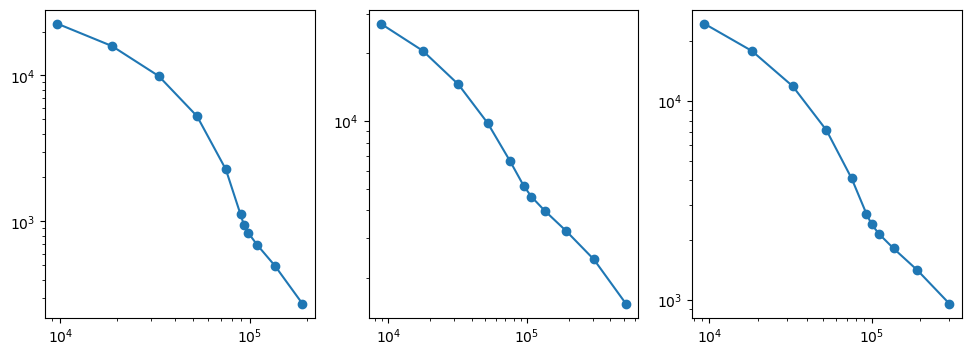

In [16]:
# L-curve
fig = plt.figure(figsize = (16, 4))

ax = fig.add_subplot(141)
ax.loglog(rss_temp_del12, pen_temp_del12, "o-")

ax = fig.add_subplot(142)
ax.loglog(rss_temp_del23, pen_temp_del23, "o-")

ax = fig.add_subplot(143)
ax.loglog(rss_temp_del34, pen_temp_del34, "o-")

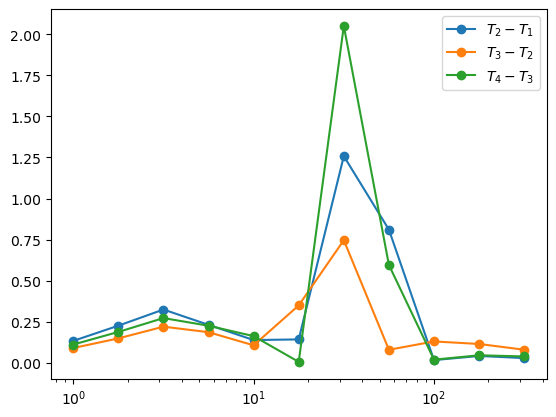

In [17]:
plt.semilogx(lams, calcCurvature2(np.log(rss_temp_del12), np.log(pen_temp_del12)), "o-", label = "$T_2 - T_1$")
plt.semilogx(lams, calcCurvature2(np.log(rss_temp_del23), np.log(pen_temp_del23)), "o-", label = "$T_3 - T_2$")
plt.semilogx(lams, calcCurvature2(np.log(rss_temp_del34), np.log(pen_temp_del34)), "o-", label = "$T_4 - T_3$")
plt.legend()